In [141]:
using ModelingToolkit, OrdinaryDiffEq, Plots
using ModelingToolkit: t, D

using ModelingToolkitStandardLibrary.Electrical
using ModelingToolkitStandardLibrary.Blocks: Step, RealInput, RealOutput

In [142]:
@mtkmodel VariableResistorSimple begin
    @extend v, i = oneport = OnePort()

    @parameters begin
        R_ref
    end

    @variables begin
        pos(t) = 1.0
        R(t)
    end

    @equations begin
        R ~ pos*R_ref
        v ~ i*R
    end
end;

In [140]:
@mtkmodel SwitchTest begin
    @parameters begin
        V = 10.0
        C = 1.0
        R = 1.0
    end

    @components begin
        voltage = Voltage()
        resistor = VariableResistorSimple(R_ref=R)
        capacitor = Capacitor(C = C)
        ground = Ground()
    end

    @equations begin
        connect(voltage.p, resistor.p)
        connect(resistor.n, capacitor.p)
        connect(voltage.n, capacitor.n, ground.g)
        voltage.V.u ~ V
        D(resistor.pos) ~ 0.0
    end

    # @continuous_events begin
    #    [t ~ 10.0] => [resistor.pos ~ resistor.pos + 1.0]
    # end
end

@mtkbuild sys = SwitchTest()
u0 = [
    sys.capacitor.v => 0.0
]
prob = ODEProblem(sys, u0, (0.0, 25.0))
sol = solve(prob, Rodas4());

┌ Warning: Did not converge after `maxiters = 100` substitutions. Either there is a cycle in the rules or `maxiters` needs to be higher.
└ @ Symbolics C:\Users\matth\.julia\packages\Symbolics\B6Z8m\src\variable.jl:587


LoadError: Cyclic guesses detected in the system. Symbolic values were found for the following variables/parameters in the map: 
resistor₊i(t)  => resistor₊p₊i(t)
In order to resolve this, please provide additional numeric guesses so that the chain can be resolved to assign numeric values to each variable.            


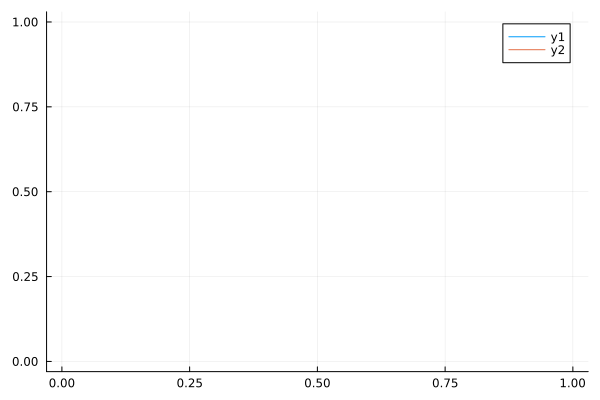

In [ ]:
plot(sol.t, sol[sys.capacitor.v])
plot!(sol.t, sol[sys.capacitor.i])

In [ ]:
sol

retcode: InitialFailure
Interpolation: specialized 4rd order "free" stiffness-aware interpolation
t: 1-element Vector{Float64}:
 0.0
u: 1-element Vector{Vector{Float64}}:
 [0.0, 1.0, 0.0]